In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/anushka1511/best-model/best_model.pth
/kaggle/input/datasets/anushka1511/image0/ISIC_0000000.jpg
/kaggle/input/models/anushka1511/best-model/pytorch/default/1/best_model.pth
/kaggle/input/models/anushka1511/res2net/pytorch/default/1/res2net_v1b.py
/kaggle/input/models/anushka1511/prafatnet/pytorch/default/1/Pra_FATNet_local.py


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


[INFO] Using device: cuda
Downloading: "https://shanghuagao.oss-cn-beijing.aliyuncs.com/res2net/res2net50_v1b_26w_4s-3cf99910.pth" to /root/.cache/torch/hub/checkpoints/res2net50_v1b_26w_4s-3cf99910.pth


100%|██████████| 98.4M/98.4M [00:08<00:00, 12.5MB/s]


Downloading: "https://github.com/facebookresearch/deit/zipball/main" to /root/.cache/torch/hub/main.zip


/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/root/.cache/torch/hub/facebookresearch_deit_main/models.py:62: UserWarning: Overwriting deit_tiny_patch16_224 in registry with models.deit_tiny_patch16_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
/root/.cache/torch/hub/facebookresearch_deit_main/models.py:77: UserWarning: Overwriting deit_small_patch16_224 in registry with models.deit_small_patch16_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
/root/.cache/torch/hub/facebookresearch_deit_main/models.py:92: UserWarning: Overwriting deit_base_patch16_224 in registry with models.deit_base_patch1

Downloading: "https://dl.fbaipublicfiles.com/deit/deit_base_distilled_patch16_384-d0272ac0.pth" to /root/.cache/torch/hub/checkpoints/deit_base_distilled_patch16_384-d0272ac0.pth


100%|██████████| 334M/334M [00:05<00:00, 66.8MB/s] 


[INFO] Model loaded from /kaggle/input/models/anushka1511/best-model/pytorch/default/1/best_model.pth
x torch.Size([1, 64, 96, 96])
x1 torch.Size([1, 256, 96, 96])
x2 torch.Size([1, 512, 48, 48])
x3 torch.Size([1, 1024, 24, 24])
x4 torch.Size([1, 2048, 12, 12])
emb torch.Size([1, 576, 768])
e3 torch.Size([1, 1024, 24, 24])
e2 torch.Size([1, 512, 48, 48])
e1 torch.Size([1, 256, 96, 96])
feature_out torch.Size([1, 2048, 12, 12])
d4 torch.Size([1, 1024, 24, 24])
d3 torch.Size([1, 512, 48, 48])
d2 torch.Size([1, 256, 96, 96])
ra5_feat torch.Size([1, 1, 48, 48])
ra4_feat torch.Size([1, 1, 12, 12])
ra3_feat torch.Size([1, 1, 24, 24])
ra2_feat torch.Size([1, 1, 48, 48])
d3 torch.Size([1, 1, 48, 48])


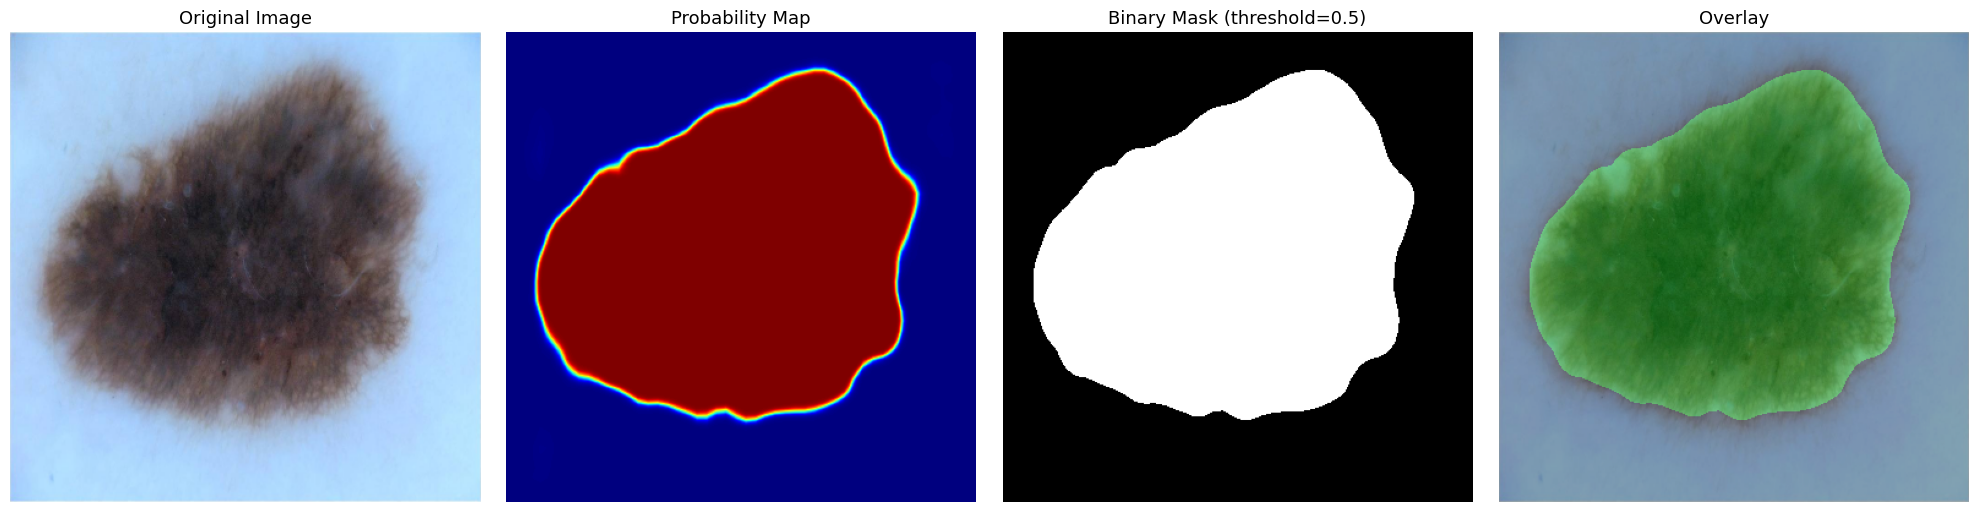

[INFO] Result saved to /kaggle/working/segmentation_result.png


In [2]:
import torch
import torch.nn.functional as F
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2

import sys

import sys
sys.path.append('/kaggle/input/models/anushka1511/res2net/pytorch/default/1/')

# Create an alias so "Res2Net_v1b" resolves to whatever the file is actually called
import res2net_v1b  # change this to match the actual filename from os.listdir
sys.modules['Res2Net_v1b'] = res2net_v1b  # this tricks Python into finding it

sys.path.append('/kaggle/input/models/anushka1511/prafatnet/pytorch/default/1/')
from Pra_FATNet_local import Pra_FATNet

# Now import
from Pra_FATNet_local import Pra_FATNet
# ==============================================================
# CONFIG
# ==============================================================
CHECKPOINT_PATH = "/kaggle/input/models/anushka1511/best-model/pytorch/default/1/best_model.pth"
IMAGE_PATH      = "/kaggle/input/datasets/anushka1511/image0/ISIC_0000000.jpg"   # <-- change this
IMG_SIZE        = 384
THRESHOLD       = 0.5
DEVICE          = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==============================================================
# LOAD MODEL
# ==============================================================
def load_model(checkpoint_path):
    model = Pra_FATNet(num_classes=1, input_channels=3, deep_supervision=True)
    model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
    model.to(DEVICE)
    model.eval()
    print(f"[INFO] Model loaded from {checkpoint_path}")
    return model

# ==============================================================
# PREPROCESS
# ==============================================================
def preprocess(image_path, img_size):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    original = image.copy()   # keep original for display

    transform = A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(mean=(0.485, 0.456, 0.406),
                    std =(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])
    augmented = transform(image=image)
    tensor = augmented["image"].unsqueeze(0)  # (1, 3, H, W)
    return tensor, original

# ==============================================================
# INFERENCE
# ==============================================================
@torch.no_grad()
def predict(model, tensor):
    tensor = tensor.to(DEVICE)
    outputs = model(tensor)          # list of 4 outputs

    # Use the final output (highest resolution / best quality)
    final_out = outputs[-1]          # (1, 1, H, W)
    final_out = F.interpolate(final_out, size=(IMG_SIZE, IMG_SIZE),
                              mode="bilinear", align_corners=False)
    prob_map = torch.sigmoid(final_out).squeeze().cpu().numpy()  # (H, W) values 0-1
    binary_mask = (prob_map > THRESHOLD).astype(np.uint8) * 255  # 0 or 255
    return prob_map, binary_mask

# ==============================================================
# VISUALIZE
# ==============================================================
def visualize(original, prob_map, binary_mask):
    # Resize original to match mask for overlay
    orig_resized = cv2.resize(original, (IMG_SIZE, IMG_SIZE))

    # Create colored overlay (green mask on image)
    overlay = orig_resized.copy()
    green_mask = np.zeros_like(orig_resized)
    green_mask[:, :, 1] = binary_mask          # green channel
    overlay = cv2.addWeighted(overlay, 0.7, green_mask, 0.3, 0)

    # Plot
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    axes[0].imshow(orig_resized)
    axes[0].set_title("Original Image", fontsize=13)
    axes[0].axis("off")

    axes[1].imshow(prob_map, cmap="jet")
    axes[1].set_title("Probability Map", fontsize=13)
    axes[1].axis("off")

    axes[2].imshow(binary_mask, cmap="gray")
    axes[2].set_title(f"Binary Mask (threshold={THRESHOLD})", fontsize=13)
    axes[2].axis("off")

    axes[3].imshow(overlay)
    axes[3].set_title("Overlay", fontsize=13)
    axes[3].axis("off")

    plt.tight_layout()
    plt.savefig("/kaggle/working/segmentation_result.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("[INFO] Result saved to /kaggle/working/segmentation_result.png")

# ==============================================================
# MAIN
# ==============================================================
model  = load_model(CHECKPOINT_PATH)
tensor, original = preprocess(IMAGE_PATH, IMG_SIZE)
prob_map, binary_mask = predict(model, tensor)
visualize(original, prob_map, binary_mask)